In [162]:
import numpy as np
import pandas as pd
import missingno
pd.set_option('display.max_columns', None)

enc = 'utf-8'

In [163]:
base_folder = 'E:/Drive/NOA/MBD-Prediction/Grid Level/data'

In [164]:
NUTS2 = 'Thrace'
YEAR = '2025'

In [165]:
data = pd.read_csv(f'{base_folder}/{NUTS2}/GR_{NUTS2}_Timeline_GRID_{YEAR}_filled.csv', encoding=enc)

In [166]:
try:
    data.drop(columns=['Unnamed: 0'], inplace=True)
except Exception:
    print("No column named \'Unnamed: 0\'")

In [167]:
try:
    data.drop(columns=['Unnamed: 0.1'], inplace=True)
except Exception:
    print("No column named \'Unnamed: 0\'")

No column named 'Unnamed: 0'


<Axes: >

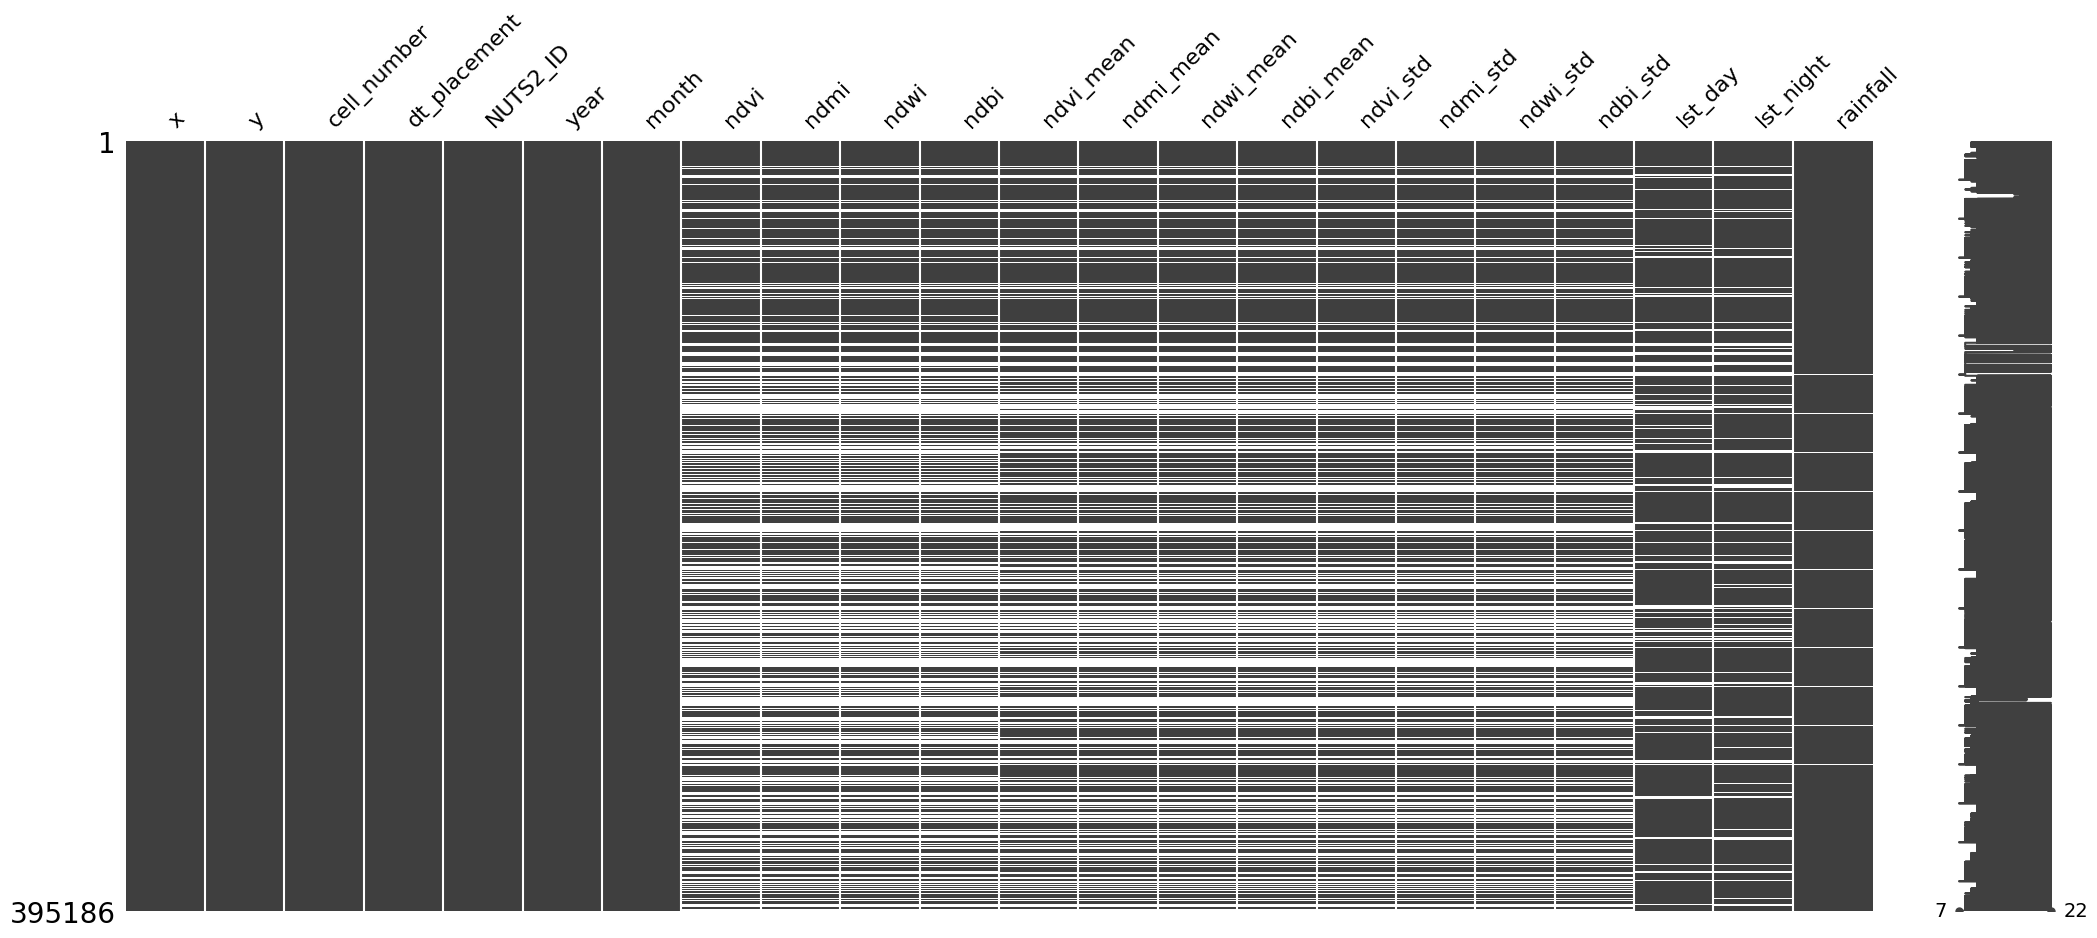

In [168]:
missingno.matrix(data)

In [169]:
data.dtypes

x               float64
y               float64
cell_number       int64
dt_placement     object
NUTS2_ID         object
year              int64
month             int64
ndvi            float64
ndmi            float64
ndwi            float64
ndbi            float64
ndvi_mean       float64
ndmi_mean       float64
ndwi_mean       float64
ndbi_mean       float64
ndvi_std        float64
ndmi_std        float64
ndwi_std        float64
ndbi_std        float64
lst_day         float64
lst_night       float64
rainfall        float64
dtype: object

In [170]:
try:
    data_old = pd.read_csv(f'{base_folder}/{NUTS2}/GR_{NUTS2}_Timeline_GRID_{YEAR}_filled_mean_rain_shp.csv', encoding=enc)
    data_old_subset = data_old[data.columns]

    data = pd.concat([data_old_subset, data], axis=0, ignore_index=True)
    missingno.matrix(data)
except FileNotFoundError as e:
    print(f"File not found: {e}")
    print("Continuing with the original data without concatenation.")

File not found: [Errno 2] No such file or directory: 'E:/Drive/NOA/MBD-Prediction/Grid Level/data/Thrace/GR_Thrace_Timeline_GRID_2025_filled_mean_rain_shp.csv'
Continuing with the original data without concatenation.


In [171]:
# data.lst_day.unique()

In [172]:
# data['lst_day'] = data['lst_day'].replace(r'\b\d{4}-\d{2}-\d{2}\b', np.nan, regex=True)

In [173]:
# data['lst_day'] = data['lst_day'].astype(float)

In [174]:
# data.drop(columns=['rainfall.1'], inplace=True)

In [175]:
data['dt_placement'] = pd.to_datetime(data['dt_placement'])

# Extract year, month, and day from the 'date' column
data['year'] = data['dt_placement'].dt.year
data['month'] = data['dt_placement'].dt.month
data['day'] = data['dt_placement'].dt.day

In [176]:
data

,x,y,cell_number,dt_placement,NUTS2_ID,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,day
0,23.65882,41.33542,0,2025-01-01,EL51,2025,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13893.0,13684.0,0.00,1
1,23.65882,41.33542,0,2025-01-02,EL51,2025,1,0.078916,0.146433,0.098425,-0.146433,0.183488,0.07095,-0.082637,-0.07095,0.087655,0.112251,0.13884,0.112251,13803.0,13667.0,0.00,2
2,23.65882,41.33542,0,2025-01-03,EL51,2025,1,0.078916,0.146433,0.098425,-0.146433,0.183488,0.07095,-0.082637,-0.07095,0.087655,0.112251,0.13884,0.112251,13803.0,13667.0,6.45,3
3,23.65882,41.33542,0,2025-01-04,EL51,2025,1,0.078916,0.146433,0.098425,-0.146433,0.183488,0.07095,-0.082637,-0.07095,0.087655,0.112251,0.13884,0.112251,13803.0,13546.0,4.76,4
4,23.65882,41.33542,0,2025-01-05,EL51,2025,1,0.078916,0.146433,0.098425,-0.146433,0.183488,0.07095,-0.082637,-0.07095,0.087655,0.112251,0.13884,0.112251,13803.0,13649.0,2.02,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395181,26.58397,41.49712,3261,2025-05-01,EL51,2025,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
395182,26.60756,41.35339,3262,2025-05-01,EL51,2025,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
395183,26.60756,41.37135,3263,2025-05-01,EL51,2025,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
395184,26.60756,41.38932,3264,2025-05-01,EL51,2025,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1


In [177]:
data_jan = data.loc[data['month'] == 1]
data_fed = data.loc[data['month'] == 2]
data_mar = data.loc[data['month'] == 3]
data_apr = data.loc[data['month'] == 4]

In [178]:
df_mean_jan = data_jan.groupby(['cell_number', 'year', 'month'], as_index=False)[['lst_day', 'lst_night']].mean()
df_mean_feb = data_fed.groupby(['cell_number', 'year', 'month'], as_index=False)[['lst_day', 'lst_night']].mean()
df_mean_mar = data_mar.groupby(['cell_number', 'year', 'month'], as_index=False)[['lst_day', 'lst_night']].mean()
df_mean_apr = data_apr.groupby(['cell_number', 'year', 'month'], as_index=False)[['lst_day', 'lst_night']].mean()

In [179]:
df_mean_jan.rename(columns={'lst_day': 'lst_day_jan_mean', 'lst_night': 'lst_night_jan_mean'}, inplace=True)
df_mean_feb.rename(columns={'lst_day': 'lst_day_feb_mean', 'lst_night': 'lst_night_feb_mean'}, inplace=True)
df_mean_mar.rename(columns={'lst_day': 'lst_day_mar_mean', 'lst_night': 'lst_night_mar_mean'}, inplace=True)
df_mean_apr.rename(columns={'lst_day': 'lst_day_apr_mean', 'lst_night': 'lst_night_apr_mean'}, inplace=True)

In [180]:
df_mean_jan.drop(columns=['month'], inplace = True)
df_mean_feb.drop(columns=['month'], inplace = True)
df_mean_mar.drop(columns=['month'], inplace = True)
df_mean_apr.drop(columns=['month'], inplace = True)

In [181]:
df_mean = pd.merge(df_mean_jan, df_mean_feb, on=['cell_number', 'year']).merge(df_mean_mar, on=['cell_number', 'year']).merge(df_mean_apr, on=['cell_number', 'year'])

In [182]:
df_mean.loc[(df_mean['cell_number'] == 0) & (df_mean['year'] == int(YEAR))]

,cell_number,year,lst_day_jan_mean,lst_night_jan_mean,lst_day_feb_mean,lst_night_feb_mean,lst_day_mar_mean,lst_night_mar_mean,lst_day_apr_mean,lst_night_apr_mean
0,0,2025,13864.935484,13732.064516,13718.714286,13448.535714,14232.535714,13851.206897,14335.652174,13977.26087


In [183]:
data_mean = pd.merge(data, df_mean, on=['cell_number', 'year'])

In [184]:
data_mean

,x,y,cell_number,dt_placement,NUTS2_ID,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,day,lst_day_jan_mean,lst_night_jan_mean,lst_day_feb_mean,lst_night_feb_mean,lst_day_mar_mean,lst_night_mar_mean,lst_day_apr_mean,lst_night_apr_mean
0,23.65882,41.33542,0,2025-01-01,EL51,2025,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13893.0,13684.0,0.00,1,13864.935484,13732.064516,13718.714286,13448.535714,14232.535714,13851.206897,14335.652174,13977.260870
1,23.65882,41.33542,0,2025-01-02,EL51,2025,1,0.078916,0.146433,0.098425,-0.146433,0.183488,0.07095,-0.082637,-0.07095,0.087655,0.112251,0.13884,0.112251,13803.0,13667.0,0.00,2,13864.935484,13732.064516,13718.714286,13448.535714,14232.535714,13851.206897,14335.652174,13977.260870
2,23.65882,41.33542,0,2025-01-03,EL51,2025,1,0.078916,0.146433,0.098425,-0.146433,0.183488,0.07095,-0.082637,-0.07095,0.087655,0.112251,0.13884,0.112251,13803.0,13667.0,6.45,3,13864.935484,13732.064516,13718.714286,13448.535714,14232.535714,13851.206897,14335.652174,13977.260870
3,23.65882,41.33542,0,2025-01-04,EL51,2025,1,0.078916,0.146433,0.098425,-0.146433,0.183488,0.07095,-0.082637,-0.07095,0.087655,0.112251,0.13884,0.112251,13803.0,13546.0,4.76,4,13864.935484,13732.064516,13718.714286,13448.535714,14232.535714,13851.206897,14335.652174,13977.260870
4,23.65882,41.33542,0,2025-01-05,EL51,2025,1,0.078916,0.146433,0.098425,-0.146433,0.183488,0.07095,-0.082637,-0.07095,0.087655,0.112251,0.13884,0.112251,13803.0,13649.0,2.02,5,13864.935484,13732.064516,13718.714286,13448.535714,14232.535714,13851.206897,14335.652174,13977.260870
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395181,26.58397,41.49712,3261,2025-05-01,EL51,2025,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,14074.655172,13763.483871,13935.720000,13558.321429,14435.774194,13891.655172,14667.291667,14046.826087
395182,26.60756,41.35339,3262,2025-05-01,EL51,2025,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,14114.225806,13897.354839,14055.392857,13559.285714,14542.322581,13867.724138,14694.000000,14060.347826
395183,26.60756,41.37135,3263,2025-05-01,EL51,2025,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,14077.612903,13895.483871,14030.142857,13554.035714,14450.612903,13876.034483,14666.750000,14076.416667
395184,26.60756,41.38932,3264,2025-05-01,EL51,2025,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,14104.903226,13878.290323,14007.320000,13548.464286,14526.709677,13885.517241,14653.083333,14065.125000


<Axes: >

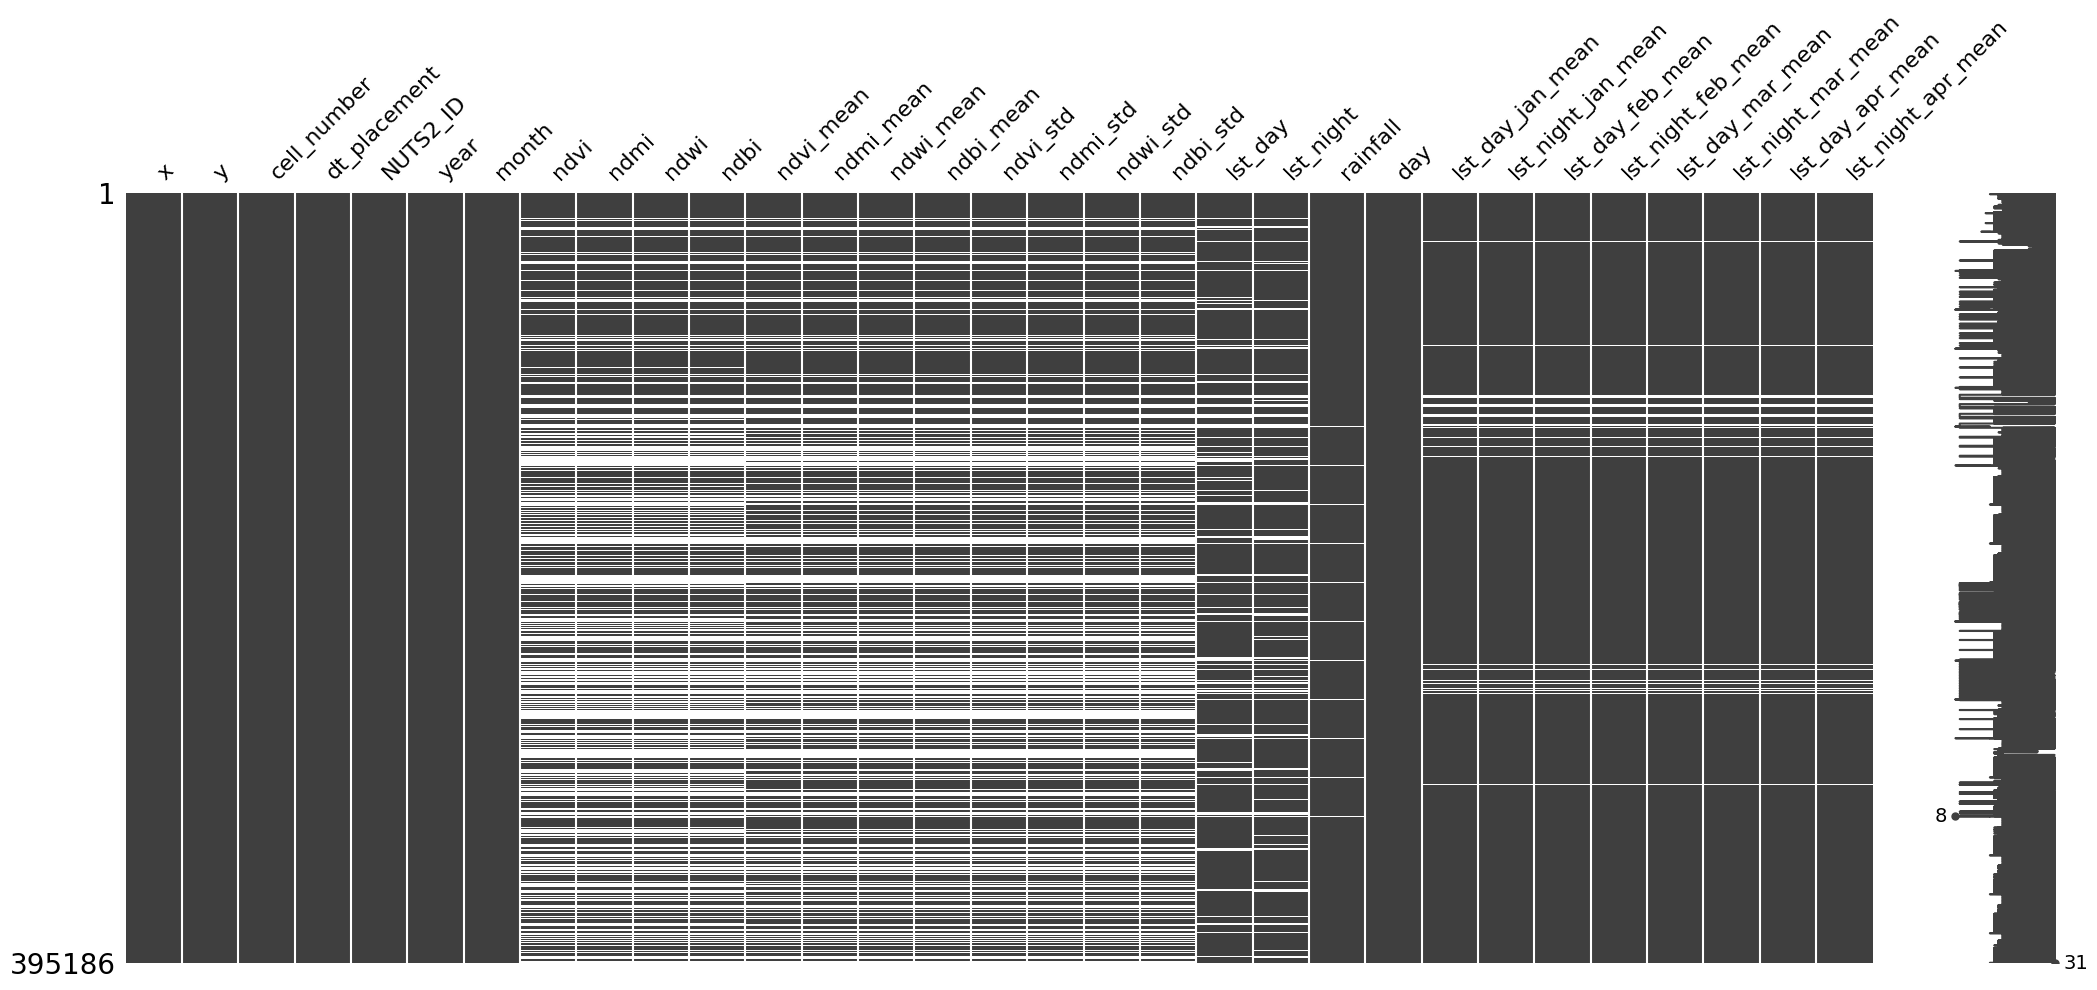

In [185]:
missingno.matrix(data_mean)

In [186]:
# to merge with the old data

data_mean = data_mean.sort_values(by=['cell_number', 'dt_placement'])
data_mean = data_mean.drop_duplicates(subset=['cell_number', 'dt_placement'], keep='last')
data_mean = data_mean.reset_index(drop=True)
counts = data_mean.groupby(['cell_number', 'dt_placement']).size().reset_index(name='count')
counts.loc[(counts['count'] > 1)]

,cell_number,dt_placement,count


<Axes: >

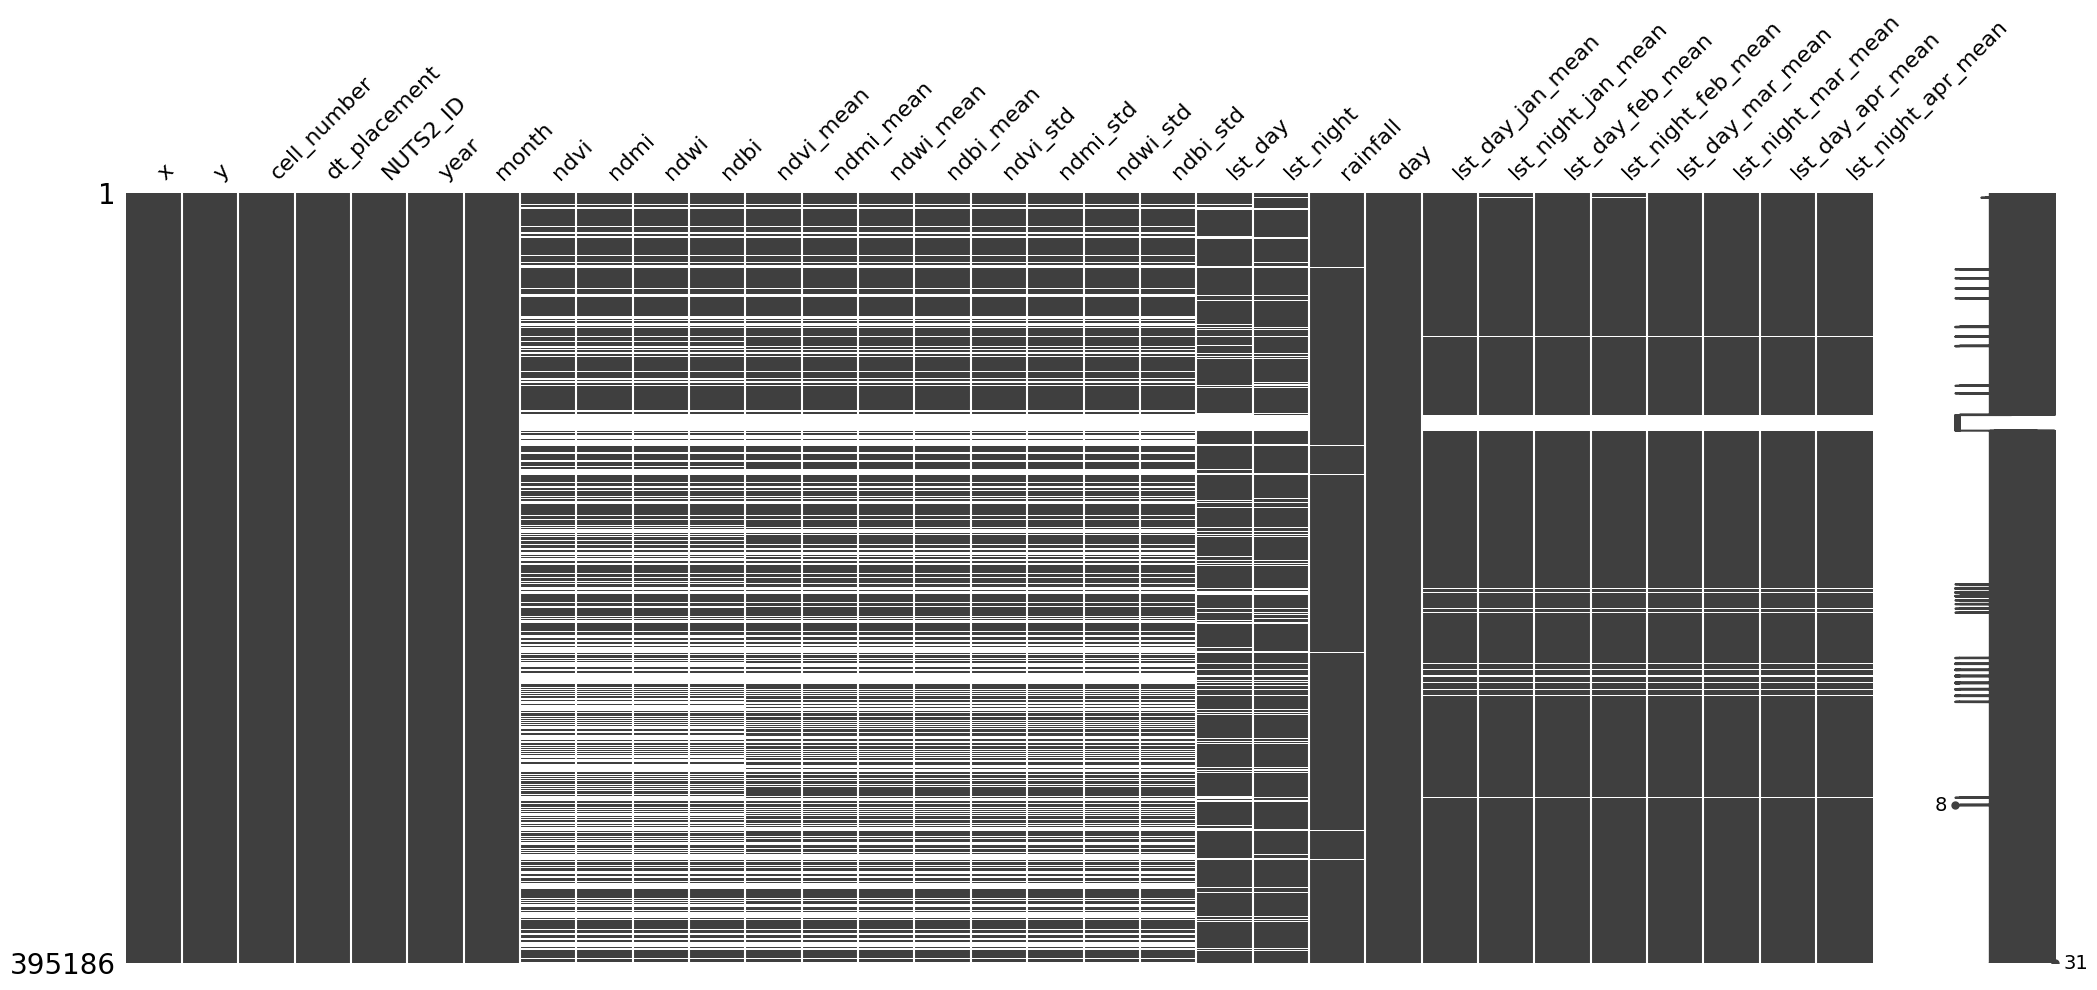

In [187]:
missingno.matrix(data_mean)

In [188]:
data_mean.to_csv(f'{base_folder}/{NUTS2}/GR_{NUTS2}_Timeline_GRID_{YEAR}_filled_mean.csv', encoding='utf-8')